# Módulo 5 (aplicación) — Series de tiempo reales: nivel de ríos y quebradas (CORNARE)

**ERA 1: Fundamentos de Computación Científica**

### ¿Qué es una API y qué es un endpoint?

Una **API** (*Application Programming Interface*) es la puerta de entrada que un sistema expone para que otros programas puedan pedirle datos o funciones, sin tener que conocer cómo está construido por dentro. En este caso, CORNARE expone una API llamada **MARCO** con información hidrometeorológica de sus estaciones (nivel de ríos, lluvia, etc.).

Un **endpoint** es una dirección (URL) específica dentro de esa API que responde a un tipo de solicitud concreto. Una misma API puede tener muchos endpoints distintos (uno para el listado de estaciones, otro para el nivel de una estación en el tiempo, otro para lluvia, etc.). En este notebook usamos el endpoint que entrega la **serie de tiempo de nivel** de una estación puntual, minuto a minuto:

```
https://marco.cornare.gov.co/api/v1/estaciones/{codigo}/nivel?desde=YYYY-MM-DD&hasta=YYYY-MM-DD&calidad=1
```

Ya conocemos la forma exacta en que responde este endpoint (sus llaves, su paginación y los nombres de sus campos), así que en este notebook vamos directo a construir y limpiar la serie de tiempo, sin pasos de exploración.

### Actividad individual

Este notebook está pensado para que **cada estudiante consulte una estación y un rango de fechas distinto**. Cambien los parámetros de la siguiente celda antes de ejecutar — así cada quien trabaja con su propio dataframe, con sus propios missing values y sus propios outliers reales, en vez de copiar el resultado de un compañero.

**Flujo del notebook:**
1. Parámetros de tu consulta (edítalos)
2. Consultar la API real y traer todas las páginas de resultados
3. Construir el DataFrame de serie de tiempo
4. Tipos de datos y orden temporal
5. Missing values reales (huecos en la serie) — método correcto: reindexar a frecuencia regular
6. Outliers con IQR + límites físicos
7. Normalización y estandarización
8. Train / validation / test — split cronológico (como corresponde a una serie de tiempo real)
9. Estadística descriptiva


## 1. Parámetros de tu consulta

⚠️ **Cada estudiante debe cambiar estos valores.** Usa un código de estación distinto al de tus compañeros (por ejemplo `2`, `18`, `204`, etc.) y, si quieres, un rango de fechas distinto. `calidad=1` normalmente indica "solo datos validados".

Las siguientes son estaciones disponibles en marco

    "Aguas": [
        "28 - San Carlos (Aguas)",
        "18 - Guatapé (Aguas)",
        "14 - Concepción (Aguas)",
        "12 - Alejandría (Aguas)",
        "11 - Abejorral (Aguas)",
        "9 - San Rafael (Aguas)",
        "8 - Argelia (Aguas)",
        "6 - Sonsón (Aguas)",
        "5 - San Luis (Aguas)",
        "42 - Peñol (Aguas)",
        "43 - San Carlos Norte (Aguas)",
        "44 - Guatapé Centro (Aguas)",
        "45 - San Rafael Centro (Aguas)",
        "46 - Alejandría Centro (Aguas)",
        "47 - Concepción Centro (Aguas)",
        "48 - Sonsón Centro (Aguas)"
    ],



In [ ]:

#  PARÁMETROS DE TU CONSULTA — cámbialos por los tuyos

NOMBRE_ESTUDIANTE = "Tu Nombre Aquí"
CODIGO_ESTACION   = "42"            # código de la estación
FECHA_DESDE       = "2026-08-30"   # formato YYYY-MM-DD
FECHA_HASTA       = "2026-09-02"   # formato YYYY-MM-DD
CALIDAD           = 1              # 1 = solo datos validados (ajusta si tu instructor indica otro valor)


print(f"Estudiante: {NOMBRE_ESTUDIANTE}")
print(f"Consultando estación {CODIGO_ESTACION} entre {FECHA_DESDE} y {FECHA_HASTA} (calidad={CALIDAD})")


Estudiante: Tu Nombre Aquí
Consultando estación 42 entre 2026-08-30 y 2026-09-02 (calidad=1)


In [ ]:
# Librerías
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)
print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


## 2. Consultando la API real (serie de tiempo por estación)

Hacemos la petición HTTP GET al endpoint de nivel, pasando el código de estación en la URL y el rango de fechas y la calidad como parámetros de consulta (`params`).


In [ ]:
API_BASE_URL = "https://marco.cornare.gov.co/api/v1/estaciones"

def obtener_serie_nivel(codigo_estacion, desde, hasta, calidad=1, verificar_ssl=False, timeout=30):
    """Consulta la serie de tiempo de nivel de una estación en un rango de fechas."""
    url = f"{API_BASE_URL}/{codigo_estacion}/nivel"
    params = {"desde": desde, "hasta": hasta, "calidad": calidad}
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Accept": "application/json, text/plain, */*",
    }
    try:
        response = requests.get(url, params=params, headers=headers, timeout=timeout, verify=verificar_ssl)
        if response.status_code == 200:
            return response.json(), None
        return None, f"HTTP {response.status_code}"
    except requests.exceptions.RequestException as e:
        return None, f"Error de red: {e}"

datos_crudos, error = obtener_serie_nivel(CODIGO_ESTACION, FECHA_DESDE, FECHA_HASTA, CALIDAD)

if error:
    print(f"❌ {error}")
else:
    print("✅ Respuesta recibida")

✅ Respuesta recibida


### 2.1 Trayendo todas las páginas

La respuesta de este endpoint viene en formato paginado (estilo Django REST Framework): un diccionario con `count`, `next`, `previous` y `values` (la lista de lecturas de esa página). Si `count` es mayor que la cantidad de registros en `values`, seguimos el enlace `next` hasta que sea `None`, acumulando los resultados.


In [ ]:
def obtener_todas_las_paginas(datos_json, verificar_ssl=False, timeout=30):
    """Sigue el campo 'next' de una respuesta paginada tipo DRF y acumula todos los 'values'."""
    todos_los_registros = list(datos_json.get("values", []))
    siguiente_url = datos_json.get("next")

    while siguiente_url:
        try:
            resp = requests.get(siguiente_url, timeout=timeout, verify=verificar_ssl)
        except requests.exceptions.RequestException as e:
            print(f"⚠️ No se pudo seguir la paginación: {e}")
            break
        if resp.status_code != 200:
            print(f"⚠️ Página siguiente respondió HTTP {resp.status_code}, deteniendo paginación.")
            break
        pagina = resp.json()
        todos_los_registros.extend(pagina.get("values", []))
        siguiente_url = pagina.get("next")

    return todos_los_registros

registros = obtener_todas_las_paginas(datos_crudos)
print(f"Total de registros obtenidos (todas las páginas): {len(registros)}")
if registros:
    print("\nEjemplo de un registro:", registros[0])


Total de registros obtenidos (todas las páginas): 4308

Ejemplo de un registro: {'id': 28088209, 'fecha': '2026-09-01T23:59:00Z', 'muestra': 497.6, 'calidad': 1, 'nivel': 152.4, 'caudal': 152.4}


## 3. Construyendo el DataFrame de serie de tiempo

Cada registro de este endpoint trae la fecha/hora en la llave `level_date` y el nivel en la llave `level`. Los renombramos directamente a `fecha` y `nivel` para el resto del notebook.


In [ ]:
LLAVE_FECHA = "level_date"
LLAVE_VALOR = "level"

if not registros:
    print("No hay registros para esta estación y rango de fechas -- prueba otro código o rango.")


In [ ]:
df = pd.DataFrame(registros)

# Renombramos a nombres estándar para el resto del notebook
df = df.rename(columns={LLAVE_FECHA: "fecha", LLAVE_VALOR: "nivel"})

# Metadatos de la consulta, útiles para identificar de quién es este dataframe
df["codigo_estacion"] = CODIGO_ESTACION
df["estudiante"] = NOMBRE_ESTUDIANTE

print(f"DataFrame construido: {df.shape[0]} lecturas x {df.shape[1]} columnas")
df.head()


DataFrame construido: 4308 lecturas x 8 columnas


,id,fecha,muestra,calidad,nivel,caudal,codigo_estacion,estudiante
0,28088209,2026-09-01T23:59:00Z,497.60,1,152.40,152.40,42,Tu Nombre Aquí
1,28088211,2026-09-01T23:58:00Z,501.20,1,148.80,148.80,42,Tu Nombre Aquí
2,28088203,2026-09-01T23:57:00Z,498.40,1,151.60,151.60,42,Tu Nombre Aquí
3,28088207,2026-09-01T23:56:00Z,499.65,1,150.35,150.35,42,Tu Nombre Aquí
4,28088204,2026-09-01T23:55:00Z,495.60,1,154.40,154.40,42,Tu Nombre Aquí


## 4. Tipos de datos y orden temporal

En una serie de tiempo real, minuto a minuto, el **orden temporal importa** desde el principio.


In [ ]:
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["nivel"] = pd.to_numeric(df["nivel"], errors="coerce")

df = df.sort_values("fecha").reset_index(drop=True)

print("Rango temporal de tu consulta:")
print("  Desde:", df["fecha"].min())
print("  Hasta:", df["fecha"].max())
df.dtypes

Rango temporal de tu consulta:
  Desde: 2026-08-30 00:00:00+00:00
  Hasta: 2026-09-01 23:59:00+00:00


,0
id,int64
fecha,"datetime64[ns, UTC]"
muestra,float64
calidad,int64
nivel,float64
caudal,float64
codigo_estacion,object
estudiante,object


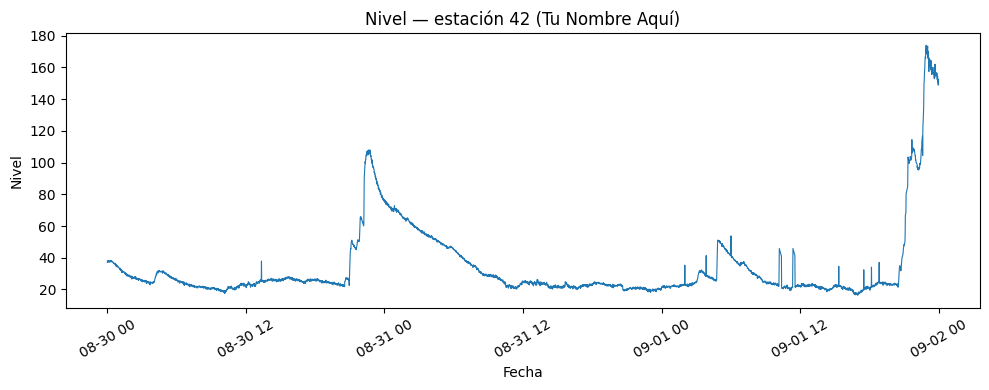

In [ ]:
# Vistazo rápido a la serie completa
plt.plot(df["fecha"], df["nivel"], linewidth=0.8)
plt.title(f"Nivel — estación {CODIGO_ESTACION} ({NOMBRE_ESTUDIANTE})")
plt.xlabel("Fecha")
plt.ylabel("Nivel")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Para pensar / practicar:**
- Si dos estudiantes consultaron la misma estación pero rangos de fechas distintos, ¿por qué sus gráficas de nivel pueden verse completamente diferentes (por ejemplo, si uno incluyó un día de lluvia fuerte)?
- ¿Por qué convertir `fecha` a `datetime` (en vez de dejarla como texto) es indispensable antes de ordenar u operar sobre la serie?

## 5. Missing values reales: huecos en la serie de tiempo

En una serie minuto a minuto, un "missing value" casi nunca aparece como `NaN` explícito — aparece como **un hueco**: el sensor debía reportar a las 10:01 y no lo hizo. Para detectarlo correctamente necesitamos comparar contra la frecuencia esperada, no solo contar `NaN` directos.

In [ ]:
# 1) ¿Cuántos NaN directos hay?
print("NaN directos en 'nivel':", df["nivel"].isna().sum())

# 2) ¿Cuál es la frecuencia típica de reporte de esta estación?
diferencias = df["fecha"].diff().dropna()
frecuencia_tipica = diferencias.mode()[0]
print("Frecuencia típica entre lecturas:", frecuencia_tipica)

# 3) Reindexamos a esa frecuencia regular para exponer los huecos reales
df_indexado = df.set_index("fecha")
rango_completo = pd.date_range(start=df_indexado.index.min(), end=df_indexado.index.max(), freq=frecuencia_tipica)
df_regular = df_indexado.reindex(rango_completo)

huecos = df_regular["nivel"].isna().sum()
print(f"\nLecturas esperadas a frecuencia regular: {len(rango_completo)}")
print(f"Lecturas realmente recibidas:            {df_indexado.shape[0]}")
print(f"Huecos reales en la serie:                {huecos} ({huecos/len(rango_completo)*100:.1f}%)")

NaN directos en 'nivel': 0
Frecuencia típica entre lecturas: 0 days 00:01:00

Lecturas esperadas a frecuencia regular: 4320
Lecturas realmente recibidas:            4308
Huecos reales en la serie:                12 (0.3%)


### 5.1 Tratamiento: aquí sí aplica interpolación temporal

Como hay una relación real de "antes/después" entre las filas, `interpolate(method="time")` es la elección correcta para rellenar los huecos, en vez de una imputación estadística (como la mediana) que ignoraría el orden temporal.


In [ ]:
df_limpio = df_regular.copy()
df_limpio["nivel"] = df_limpio["nivel"].interpolate(method="time")

# Puede quedar NaN al inicio/final si la serie empieza o termina con huecos -- ahí no hay "antes" o "después" que interpolar
df_limpio["nivel"] = df_limpio["nivel"].ffill().bfill()

print("Missing values restantes:", df_limpio["nivel"].isna().sum())
df_limpio = df_limpio.reset_index().rename(columns={"index": "fecha"})
df_limpio.head()

Missing values restantes: 0


,fecha,id,muestra,calidad,nivel,caudal,codigo_estacion,estudiante
0,2026-08-30 00:00:00+00:00,27915732.0,612.25,1.0,37.75,37.75,42,Tu Nombre Aquí
1,2026-08-30 00:01:00+00:00,27915784.0,613.00,1.0,37.00,37.00,42,Tu Nombre Aquí
2,2026-08-30 00:02:00+00:00,27915820.0,612.95,1.0,37.05,37.05,42,Tu Nombre Aquí
3,2026-08-30 00:03:00+00:00,27915853.0,612.35,1.0,37.65,37.65,42,Tu Nombre Aquí
4,2026-08-30 00:04:00+00:00,27915889.0,611.70,1.0,38.30,38.30,42,Tu Nombre Aquí


**Para pensar / practicar:**
- ¿Por qué `interpolate(method="time")` es más apropiado aquí que una interpolación lineal simple por posición (`method="linear"`), dado que los huecos pueden tener duraciones distintas?
- Si tu serie tiene un hueco de varias **horas** (no solo minutos), ¿confiarías igual en el valor interpolado? ¿Cuándo dejarías de interpolar y mejor recortarías ese tramo?

Identifiquemos las estadisticas de la variable nivel en el periodo de consulta:

In [ ]:
df["nivel"].agg(["mean", "var", "std", "min", "max"])

,nivel
mean,34.354396
var,609.647825
std,24.691047
min,16.500000
max,173.900000


Identifiquemos el máximo y la fecha de ocurrencia de este evento:

In [ ]:
df.max()

,0
id,28088211
fecha,2026-09-01 23:59:00+00:00
muestra,633.5
calidad,1
nivel,173.9
caudal,173.9
codigo_estacion,42
estudiante,Tu Nombre Aquí


## 6. Outliers: método IQR + límites físicos

Detectamos outliers combinando el método estadístico IQR con un límite físico: en un río el nivel **no puede ser negativo**, así que ese límite se aplica antes o junto con el estadístico.


In [ ]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return (serie < limite_inferior) | (serie > limite_superior), limite_inferior, limite_superior

outliers_estadisticos, lim_inf, lim_sup = detectar_outliers_iqr(df_limpio["nivel"])
outliers_fisicos = df_limpio["nivel"] < 0  # un nivel negativo no tiene sentido físico

print(f"Rango estadístico esperado (IQR): [{lim_inf:.2f}, {lim_sup:.2f}]")
print(f"Outliers estadísticos: {outliers_estadisticos.sum()}")
print(f"Outliers físicamente imposibles (nivel < 0): {outliers_fisicos.sum()}")

outliers_mask = outliers_estadisticos | outliers_fisicos
df_limpio.loc[outliers_mask, ["fecha", "nivel"]]

Rango estadístico esperado (IQR): [3.44, 53.21]
Outliers estadísticos: 547
Outliers físicamente imposibles (nivel < 0): 0


,fecha,nivel
1311,2026-08-30 21:51:00+00:00,54.65
1312,2026-08-30 21:52:00+00:00,58.80
1313,2026-08-30 21:53:00+00:00,62.55
1314,2026-08-30 21:54:00+00:00,64.25
1315,2026-08-30 21:55:00+00:00,65.60
...,...,...
4315,2026-09-01 23:55:00+00:00,154.40
4316,2026-09-01 23:56:00+00:00,150.35
4317,2026-09-01 23:57:00+00:00,151.60
4318,2026-09-01 23:58:00+00:00,148.80


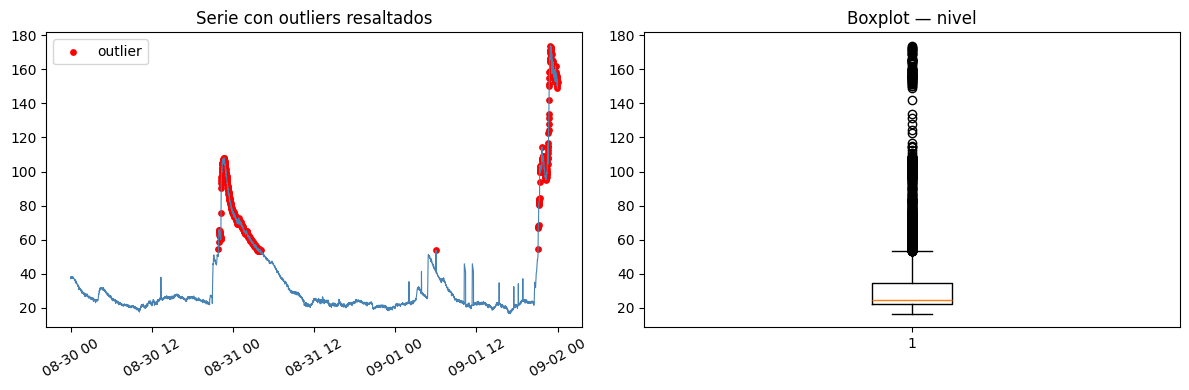

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_limpio["fecha"], df_limpio["nivel"], linewidth=0.8, color="steelblue")
axes[0].scatter(df_limpio.loc[outliers_mask, "fecha"], df_limpio.loc[outliers_mask, "nivel"], color="red", s=15, label="outlier")
axes[0].set_title("Serie con outliers resaltados")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

axes[1].boxplot(df_limpio["nivel"].dropna())
axes[1].set_title("Boxplot — nivel")

plt.tight_layout()
plt.show()

df_sin_outliers = df_limpio[~outliers_mask].copy()

**Para pensar / practicar:**
- Un pico repentino de nivel también podría ser una **crecida súbita real** (justo lo que Marco está diseñado para detectar), no un error de sensor. En este contexto, ¿eliminar el outlier automáticamente es siempre buena idea?
- ¿Cambiarías el multiplicador `1.5` del IQR si supieras que tu rango de fechas incluyó un día de lluvia fuerte?

## 7. Normalización y estandarización


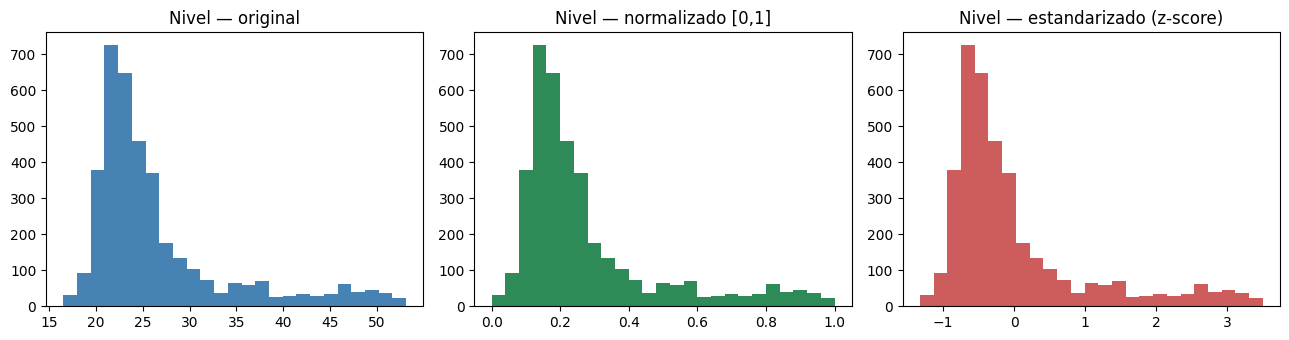

In [ ]:
def normalizar_min_max(X):
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    return (X - X_min) / (X_max - X_min), X_min, X_max

def estandarizar_zscore(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma

X = df_sin_outliers[["nivel"]].to_numpy()

X_norm, X_min, X_max = normalizar_min_max(X)
X_std, mu, sigma = estandarizar_zscore(X)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(X[:, 0], bins=25, color="steelblue"); axes[0].set_title("Nivel — original")
axes[1].hist(X_norm[:, 0], bins=25, color="seagreen"); axes[1].set_title("Nivel — normalizado [0,1]")
axes[2].hist(X_std[:, 0], bins=25, color="indianred"); axes[2].set_title("Nivel — estandarizado (z-score)")
plt.tight_layout()
plt.show()

## 8. Train / validation / test — split cronológico

Al ser una **serie de tiempo real**, un split aleatorio filtraría información del futuro hacia el pasado. Por eso usamos un split cronológico: entrenamos con los datos más antiguos y evaluamos con los más recientes.


In [ ]:
df_ordenado = df_sin_outliers.sort_values("fecha").reset_index(drop=True)
n_total = len(df_ordenado)

corte_train = int(n_total * 0.70)
corte_val = int(n_total * 0.85)

train_temporal = df_ordenado.iloc[:corte_train]
val_temporal = df_ordenado.iloc[corte_train:corte_val]
test_temporal = df_ordenado.iloc[corte_val:]

print(f"Train:      {train_temporal['fecha'].min()}  →  {train_temporal['fecha'].max()}  ({len(train_temporal)} filas)")
print(f"Validation: {val_temporal['fecha'].min()}  →  {val_temporal['fecha'].max()}  ({len(val_temporal)} filas)")
print(f"Test:       {test_temporal['fecha'].min()}  →  {test_temporal['fecha'].max()}  ({len(test_temporal)} filas)")

Train:      2026-08-30 00:00:00+00:00  →  2026-09-01 02:12:00+00:00  (2641 filas)
Validation: 2026-09-01 02:13:00+00:00  →  2026-09-01 11:39:00+00:00  (566 filas)
Test:       2026-09-01 11:40:00+00:00  →  2026-09-01 21:05:00+00:00  (566 filas)


**Para pensar / practicar:**
- ¿Por qué el conjunto de test debe ser el tramo **más reciente** de tu serie, y no uno tomado al azar?
- Si tu rango de fechas fue muy corto (por ejemplo, solo 2 días), ¿tienes suficientes datos para hacer un split en tres partes con sentido?

## 9. Estadística descriptiva

In [ ]:
resumen = df_sin_outliers["nivel"].agg(["mean", "var", "std", "min", "max"])
resumen.round(3)

,nivel
mean,26.578
var,57.560
std,7.587
min,16.500
max,53.150


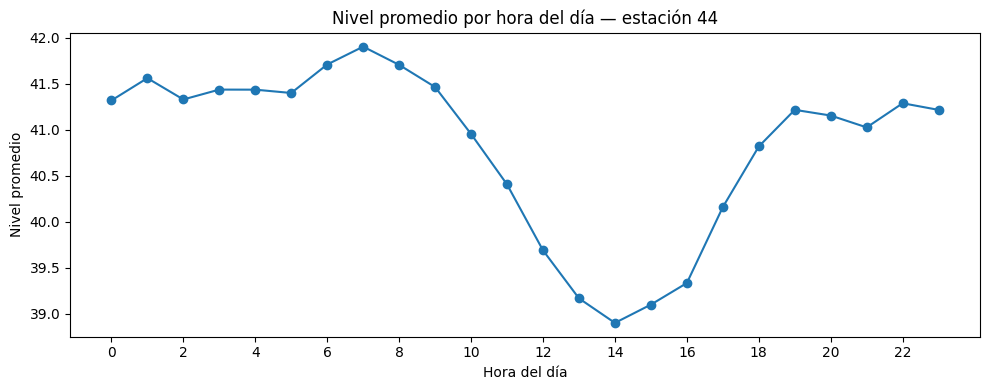

In [ ]:
# Estadística por día, para ver si hay un patrón (ej. picos en ciertas horas del día)
df_sin_outliers["hora"] = df_sin_outliers["fecha"].dt.hour
promedio_por_hora = df_sin_outliers.groupby("hora")["nivel"].mean()

plt.plot(promedio_por_hora.index, promedio_por_hora.values, marker="o")
plt.title(f"Nivel promedio por hora del día — estación {CODIGO_ESTACION}")
plt.xlabel("Hora del día")
plt.ylabel("Nivel promedio")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

**Para pensar / practicar:**
- ¿Tu estación muestra algún patrón horario claro (por ejemplo, niveles más altos en la tarde por lluvias convectivas típicas del Oriente antioqueño)? Compáralo con el de un compañero que haya consultado una estación en otra región.

## Cierre del módulo

En este notebook trabajaste con **datos reales** de una serie de tiempo genuina (una estación de nivel de río/quebrada), con:

- **Missing values reales**: huecos de reporte del sensor, detectados al reindexar a la frecuencia esperada (no simples `NaN`).
- **Outliers reales**: combinando el método estadístico IQR con un límite físico (el nivel no puede ser negativo).
- **Split cronológico**: train / validation / test respetando el orden temporal, como corresponde a cualquier serie de tiempo real.

### Resumen de tu consulta


In [ ]:
print("="*50)
print("RESUMEN DE LA CONSULTA")
print("="*50)
print(f"Estudiante:        {NOMBRE_ESTUDIANTE}")
print(f"Estación:          {CODIGO_ESTACION}")
print(f"Rango de fechas:   {FECHA_DESDE} → {FECHA_HASTA}")
print(f"Calidad:           {CALIDAD}")
print(f"Lecturas crudas:   {len(df)}")
print(f"Lecturas limpias:  {len(df_sin_outliers)}")
print(f"Huecos detectados: {huecos}")
print(f"Outliers removidos:{outliers_mask.sum()}")
print("="*50)

### Para el instructor

Cada estudiante debería tener, al final, un DataFrame `df_sin_outliers` distinto — con distinto número de filas, distinto rango de fechas y probablemente distinta cantidad de huecos y outliers, según la estación y el rango que haya elegido. El bloque de resumen anterior sirve como evidencia rápida de que el trabajo fue hecho con datos propios.